In [100]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [76]:
index = { "^FCHI"       : "CAC40",
          "^GDAXI"      : "DAX40",
          "^FTSE"       : "FTSE100", 
          "^STOXX50E"   : "EUROSTOXX50"}

index_p = yf.download(list(index.keys()), start="1990-03-01")["Close"]
index_p = index_p.rename(columns=index)

index_retD = np.log(index_p).diff()
index_retD = index_retD.dropna()

C:\Users\preet\AppData\Local\Temp\ipykernel_18284\1452545866.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  index_p = yf.download(list(index.keys()), start="1990-03-01")["Close"]
[*********************100%***********************]  4 of 4 completed


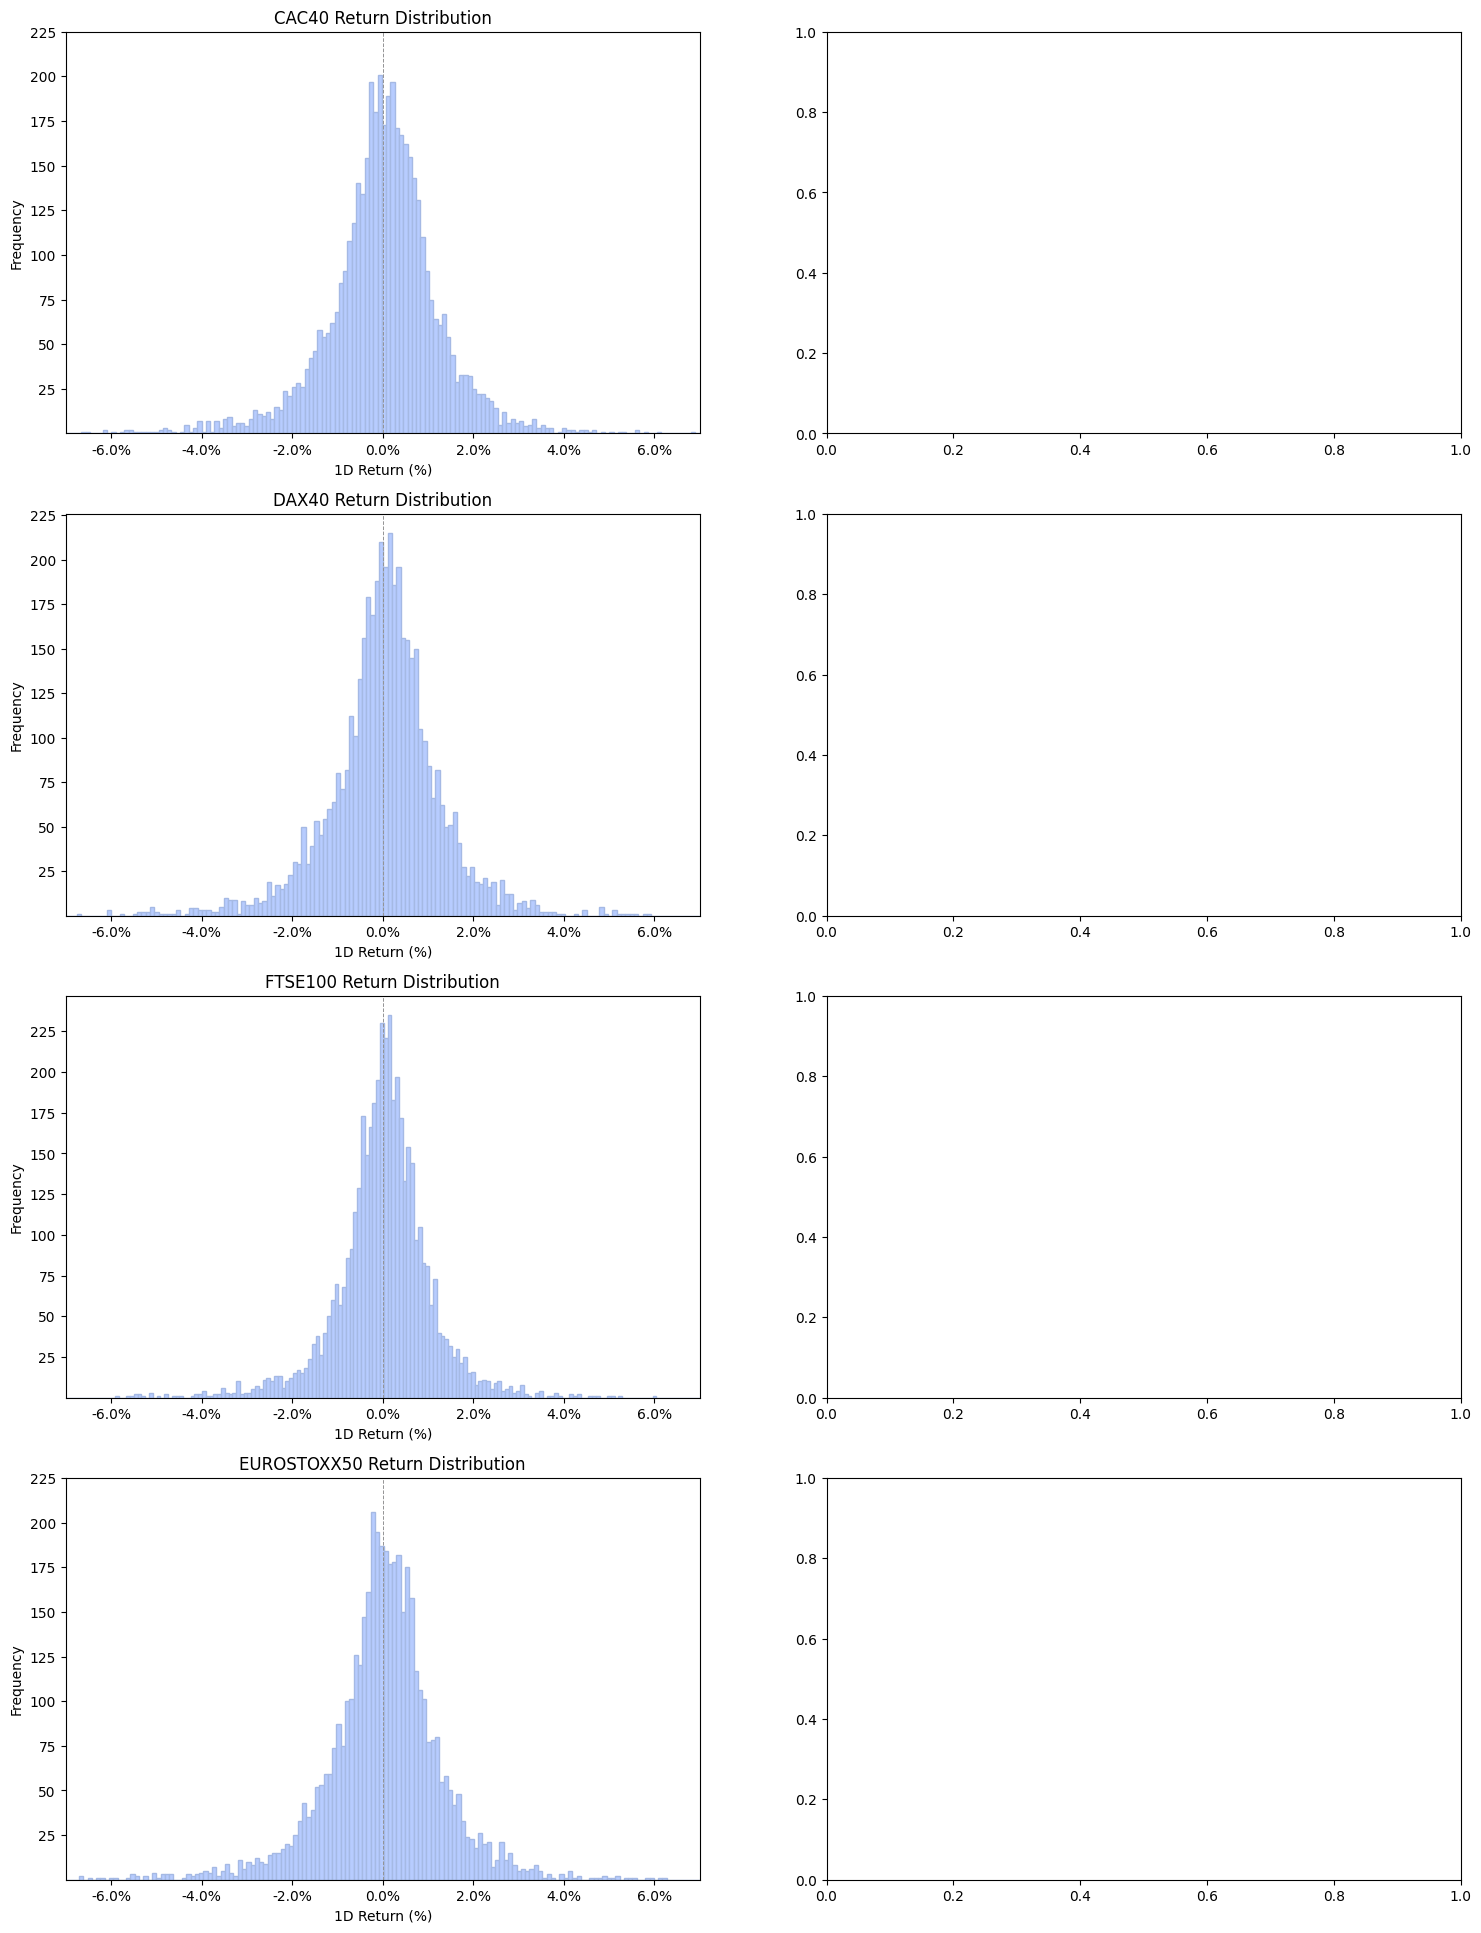

In [111]:
fig, axes = plt.subplots(4,2,figsize=(18,24))

y_data = [(index_retD[i], i) for i in list(index.values())]
y_ticks = np.arange(25,250,25)
x_ticks = np.arange(-.1, .1, .02)

for idx, (y_val, title) in enumerate(y_data):
    ax = axes[idx,0]

    ax.hist(y_val, bins=250, color="#B7CCFF", edgecolor="#A5B9E4")

    ax.set_xticks(x_ticks, labels=[f"{i:.1%}" for i in x_ticks])
    ax.set_xlim(xmin=-0.07, xmax=0.07)

    ax.set_yticks(y_ticks)

    ax.axvline(0, lw=0.7, color="#939394", ls="--")

    ax.set_ylabel("Frequency")
    ax.set_xlabel("1D Return (%)")
    ax.set_title(f"{title} Return Distribution")

plt.show()